In [2]:
import pandas as pd
import psycopg2
import numpy as np

# ==========================================
# 1. ดึงและจัดการข้อมูลจาก GitHub
# ==========================================
github_url = "https://raw.githubusercontent.com/langsari/big-data-fin-2026/refs/heads/main/shifa_set_datafin/data/raw/listedCompanies_th_TH.csv"
print("กำลังดึงข้อมูลจาก GitHub...")

try:
    # ใช้ skiprows=1 เพื่อข้ามบรรทัดแรกที่เป็นแค่ชื่อ Title
    df = pd.read_csv(github_url, encoding='utf-8', skiprows=1)
except UnicodeDecodeError:
    df = pd.read_csv(github_url, encoding='tis-620', skiprows=1)

# เปลี่ยนชื่อคอลัมน์ภาษาไทย ให้เป็นภาษาอังกฤษเพื่อให้เหมาะกับ Database
df.rename(columns={
    'หลักทรัพย์': 'symbol',
    'บริษัท': 'company_name_th',
    'ตลาด': 'market',
    'กลุ่มอุตสาหกรรม': 'industry_group',
    'หมวดธุรกิจ': 'sector_th',
    'ที่อยู่': 'address',
    'รหัสไปรษณีย์': 'zipcode',
    'โทรศัพท์': 'phone',
    'โทรสาร': 'fax',
    'เว๊บไซต์': 'website'
}, inplace=True)

# แปลงค่าที่เป็น NaN (ค่าว่าง) ให้เป็น None เพื่อให้ SQL ไม่พัง
df = df.replace({np.nan: None})

# กรองเอาเฉพาะหุ้นสามัญ (ตัดพวกที่มีขีด - ออก)
df = df[~df['symbol'].str.contains('-', na=False)]

print(f"เตรียมข้อมูลสำเร็จ! จำนวนหุ้นทั้งหมดที่จะบันทึก: {len(df)} บริษัท")

# ==========================================
# 2. เชื่อมต่อ Database และสร้าง Table ใหม่
# ==========================================
print("\nกำลังเชื่อมต่อ Database 'set_quant'...")
try:
    conn = psycopg2.connect(
        host="127.0.0.1",
        database="set_quant",
        user="postgres",
        password="Shifa.326459"
    )
    cur = conn.cursor()

    # สร้างตารางใหม่ชื่อ set_companies_list
    create_table_sql = """
    CREATE TABLE IF NOT EXISTS set_companies_list (
        symbol VARCHAR(20) PRIMARY KEY,
        company_name_th VARCHAR(255),
        market VARCHAR(50),
        industry_group VARCHAR(100),
        sector_th VARCHAR(100),
        address TEXT,
        zipcode VARCHAR(20),
        phone VARCHAR(100),
        fax VARCHAR(100),
        website VARCHAR(255),
        updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    );
    """
    cur.execute(create_table_sql)
    print("✅ สร้างตาราง 'set_companies_list' สำเร็จ (หรือมีอยู่แล้ว)")

    # ==========================================
    # 3. นำข้อมูล (DataFrame) ยัดลง Database
    # ==========================================
    insert_sql = """
        INSERT INTO set_companies_list (
            symbol, company_name_th, market, industry_group, sector_th, 
            address, zipcode, phone, fax, website
        ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
        ON CONFLICT (symbol) 
        DO UPDATE SET 
            company_name_th = EXCLUDED.company_name_th,
            market = EXCLUDED.market,
            industry_group = EXCLUDED.industry_group,
            sector_th = EXCLUDED.sector_th,
            address = EXCLUDED.address,
            zipcode = EXCLUDED.zipcode,
            phone = EXCLUDED.phone,
            fax = EXCLUDED.fax,
            website = EXCLUDED.website,
            updated_at = CURRENT_TIMESTAMP;
    """

    # วนลูปบันทึกทีละรายการ
    success_count = 0
    for index, row in df.iterrows():
        try:
            # เก็บ symbol ต้นฉบับไว้ เช่น '2S'
            cur.execute(insert_sql, (
                str(row['symbol']).strip(),
                row['company_name_th'],
                row['market'],
                row['industry_group'],
                row['sector_th'],
                row['address'],
                row['zipcode'],
                row['phone'],
                row['fax'],
                row['website']
            ))
            success_count += 1
        except Exception as insert_e:
            print(f"❌ บันทึกผิดพลาดที่หุ้น {row['symbol']}: {insert_e}")
            conn.rollback() # ถ้ามีปัญหาบางตัว ให้ดึงกลับแล้วไปทำตัวถัดไป
            continue

    conn.commit()
    print(f"🎉 บันทึกข้อมูลลงฐานข้อมูลสำเร็จ {success_count} / {len(df)} รายการ!")

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาดกับ Database: {e}")

กำลังดึงข้อมูลจาก GitHub...
เตรียมข้อมูลสำเร็จ! จำนวนหุ้นทั้งหมดที่จะบันทึก: 925 บริษัท

กำลังเชื่อมต่อ Database 'set_quant'...
✅ สร้างตาราง 'set_companies_list' สำเร็จ (หรือมีอยู่แล้ว)
🎉 บันทึกข้อมูลลงฐานข้อมูลสำเร็จ 925 / 925 รายการ!


In [9]:
import pandas as pd
import yfinance as yf
import psycopg2
import json
import time

# ==========================================
# 1. เชื่อมต่อ Database และดึงรายชื่อหุ้น
# ==========================================
print("1. Connecting to Database...")
try:
    conn = psycopg2.connect(
        host="127.0.0.1",
        database="set_quant",
        user="postgres",
        password="Shifa.326459"
    )
    cur = conn.cursor()

    # ดึงรายชื่อหุ้นทั้งหมดจากตารางที่เราสร้างไว้ก่อนหน้านี้
    cur.execute("SELECT symbol FROM set_companies_list")
    db_symbols = cur.fetchall()
    
    # เติม .BK ต่อท้ายให้พร้อมใช้งานกับ yfinance และเอาช่องว่างออก
    stock_symbols = [f"{row[0].strip()}.BK" for row in db_symbols]
    print(f"✅ Found {len(stock_symbols)} stocks in the database.")

    # ==========================================
    # 2. สร้าง Table สำหรับเก็บข้อมูล yfinance info
    # ==========================================
    print("\n2. Creating 'yfinance_stock_info' table...")
    create_table_sql = """
    CREATE TABLE IF NOT EXISTS yfinance_stock_info (
        symbol VARCHAR(20) PRIMARY KEY,
        long_name VARCHAR(255),
        sector VARCHAR(100),
        industry VARCHAR(100),
        market_cap BIGINT,
        beta FLOAT,
        dividend_yield FLOAT,
        five_year_avg_dividend_yield FLOAT,
        trailing_pe FLOAT,
        current_price FLOAT,
        fifty_two_week_high FLOAT,
        fifty_two_week_low FLOAT,
        raw_info_json JSONB,
        updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    );
    """
    cur.execute(create_table_sql)
    conn.commit()
    print("✅ Table created successfully.")

    # ==========================================
    # 3. วนลูปดึงข้อมูลจาก yfinance และบันทึกลง Database
    # ==========================================
    print("\n3. Start fetching data from yfinance...")
    
    insert_sql = """
        INSERT INTO yfinance_stock_info (
            symbol, long_name, sector, industry, market_cap, beta, 
            dividend_yield, five_year_avg_dividend_yield, trailing_pe, 
            current_price, fifty_two_week_high, fifty_two_week_low, raw_info_json
        ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
        ON CONFLICT (symbol) 
        DO UPDATE SET 
            long_name = EXCLUDED.long_name,
            sector = EXCLUDED.sector,
            industry = EXCLUDED.industry,
            market_cap = EXCLUDED.market_cap,
            beta = EXCLUDED.beta,
            dividend_yield = EXCLUDED.dividend_yield,
            five_year_avg_dividend_yield = EXCLUDED.five_year_avg_dividend_yield,
            trailing_pe = EXCLUDED.trailing_pe,
            current_price = EXCLUDED.current_price,
            fifty_two_week_high = EXCLUDED.fifty_two_week_high,
            fifty_two_week_low = EXCLUDED.fifty_two_week_low,
            raw_info_json = EXCLUDED.raw_info_json,
            updated_at = CURRENT_TIMESTAMP;
    """

    success_count = 0
    # หมายเหตุ: ถ้าอยากรันทดสอบก่อน ให้แก้ stock_symbols เป็น stock_symbols[:5]
    for sym in stock_symbols: 
        try:
            print(f"⏳ Fetching info for {sym}...", end=" ")
            
            ticker = yf.Ticker(sym)
            info = ticker.info
            
            # เช็คว่า yfinance มีข้อมูลหุ้นตัวนี้จริงไหม (บางตัวโดน SP หรือเพิกถอน)
            if 'regularMarketPrice' not in info and 'currentPrice' not in info and 'sector' not in info:
                print("❌ Skipped (No valid data found)")
                continue

            # สกัดตัวแปรที่สำคัญ (ถ้าไม่มีให้คืนค่า None)
            # ตัด .BK ออกตอนเซฟลง Database จะได้นำไป join กับตาราง set_companies_list ได้ง่ายๆ
            clean_symbol = sym.replace('.BK', '') 
            
            long_name = info.get('longName')
            sector = info.get('sector')
            industry = info.get('industry')
            market_cap = info.get('marketCap')
            beta = info.get('beta')
            dividend_yield = info.get('dividendYield')
            five_yr_div = info.get('fiveYearAvgDividendYield')
            trailing_pe = info.get('trailingPE')
            current_price = info.get('currentPrice', info.get('regularMarketPrice'))
            high_52 = info.get('fiftyTwoWeekHigh')
            low_52 = info.get('fiftyTwoWeekLow')
            
            # แพ็กข้อมูลทั้งก้อนเป็น JSON string
            raw_info_json = json.dumps(info)

            # บันทึกลง Database
            cur.execute(insert_sql, (
                clean_symbol, long_name, sector, industry, market_cap, beta,
                dividend_yield, five_yr_div, trailing_pe, current_price,
                high_52, low_52, raw_info_json
            ))
            conn.commit()
            
            print("✅ Success!")
            success_count += 1
            
            # พัก 1 วินาที เพื่อไม่ให้ Yahoo Finance บล็อก IP ของเรา
            time.sleep(1)

        except Exception as fetch_err:
            print(f"❌ Error: {fetch_err}")
            conn.rollback() # ถ้ารันพัง ยกเลิกเฉพาะตัวนี้ แล้วข้ามไปทำตัวถัดไป
            continue

    print(f"\n🎉 ALL DONE! Saved {success_count} / {len(stock_symbols)} stocks into 'yfinance_stock_info'.")

except Exception as e:
    print(f"❌ Database Error: {e}")
finally:
    if 'conn' in locals() and conn:
        cur.close()
        conn.close()
        print("🔒 Database connection closed.")

1. Connecting to Database...
✅ Found 925 stocks in the database.

2. Creating 'yfinance_stock_info' table...
✅ Table created successfully.

3. Start fetching data from yfinance...
⏳ Fetching info for 2S.BK... ✅ Success!
⏳ Fetching info for 3BBIF.BK... ✅ Success!
⏳ Fetching info for 88TH.BK... ✅ Success!
⏳ Fetching info for A.BK... ✅ Success!
⏳ Fetching info for A5.BK... ✅ Success!
⏳ Fetching info for AAI.BK... ✅ Success!
⏳ Fetching info for AAV.BK... ✅ Success!
⏳ Fetching info for ABM.BK... ✅ Success!
⏳ Fetching info for ACAP.BK... ✅ Success!
⏳ Fetching info for ACC.BK... ✅ Success!
⏳ Fetching info for ACE.BK... ✅ Success!
⏳ Fetching info for ACG.BK... ✅ Success!
⏳ Fetching info for ADB.BK... ✅ Success!
⏳ Fetching info for ADD.BK... ✅ Success!
⏳ Fetching info for ADVANC.BK... ✅ Success!
⏳ Fetching info for ADVICE.BK... ✅ Success!
⏳ Fetching info for AE.BK... ✅ Success!
⏳ Fetching info for AEONTS.BK... ✅ Success!
⏳ Fetching info for AF.BK... ✅ Success!
⏳ Fetching info for AFC.BK... ✅ Su

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: WELL.BK"}}}


❌ Skipped (No valid data found)
⏳ Fetching info for WFX.BK... ✅ Success!
⏳ Fetching info for WGE.BK... ✅ Success!
⏳ Fetching info for WHA.BK... ✅ Success!
⏳ Fetching info for WHABT.BK... ✅ Success!
⏳ Fetching info for WHAIR.BK... ✅ Success!
⏳ Fetching info for WHART.BK... ✅ Success!
⏳ Fetching info for WHAUP.BK... ✅ Success!
⏳ Fetching info for WICE.BK... ✅ Success!
⏳ Fetching info for WIIK.BK... ✅ Success!
⏳ Fetching info for WIN.BK... ✅ Success!
⏳ Fetching info for WINDOW.BK... ✅ Success!
⏳ Fetching info for WINMED.BK... ✅ Success!
⏳ Fetching info for WINNER.BK... ✅ Success!
⏳ Fetching info for WORK.BK... ✅ Success!
⏳ Fetching info for WP.BK... ✅ Success!
⏳ Fetching info for WPH.BK... ✅ Success!
⏳ Fetching info for WSOL.BK... ✅ Success!
⏳ Fetching info for XBIO.BK... ✅ Success!
⏳ Fetching info for XO.BK... ✅ Success!
⏳ Fetching info for XPG.BK... ✅ Success!
⏳ Fetching info for XYZ.BK... ✅ Success!
⏳ Fetching info for YGG.BK... ✅ Success!
⏳ Fetching info for YONG.BK... ✅ Success!
⏳ Fe

In [16]:
df.head(10)

,symbol,company_name,industry_group,sector_th,market_cap,current_price,beta,dividend_yield
0,2S,บริษัท 2 เอส เมทัล จำกัด (มหาชน),สินค้าอุตสาหกรรม,เหล็ก และ ผลิตภัณฑ์โลหะ,1.429990e+09,2.60,0.314,9.02
1,3BBIF,กองทุนรวมโครงสร้างพื้นฐานบรอดแบนด์อินเทอร์เน็ต...,เทคโนโลยี,เทคโนโลยีสารสนเทศและการสื่อสาร,NaN,6.60,NaN,NaN
2,88TH,บริษัท 88(ไทยแลนด์) จำกัด (มหาชน),สินค้าอุปโภคบริโภค,-,1.083750e+09,5.10,NaN,NaN
3,A,บริษัท อารียา พรอพเพอร์ตี้ จำกัด (มหาชน),อสังหาริมทรัพย์และก่อสร้าง,พัฒนาอสังหาริมทรัพย์,4.743200e+09,4.84,0.068,NaN
4,A5,บริษัท แอสเซท ไฟว์ กรุ๊ป จำกัด (มหาชน),อสังหาริมทรัพย์และก่อสร้าง,พัฒนาอสังหาริมทรัพย์,2.155740e+09,1.83,0.208,2.73
5,AAI,บริษัท เอเชี่ยน อะไลอันซ์ อินเตอร์เนชั่นแนล จำ...,เกษตรและอุตสาหกรรมอาหาร,อาหารและเครื่องดื่ม,8.520248e+09,4.02,-0.014,6.46
6,AAV,บริษัท เอเชีย เอวิเอชั่น จำกัด (มหาชน),บริการ,ขนส่งและโลจิสติกส์,1.554850e+10,1.21,NaN,NaN
7,ABM,บริษัท เอเชีย ไบโอแมส จำกัด (มหาชน),ทรัพยากร,-,4.221935e+08,0.61,NaN,NaN
8,ACAP,บริษัท เอเชีย แคปปิตอล กรุ๊ป จำกัด (มหาชน),ธุรกิจการเงิน,-,1.341157e+08,0.33,NaN,NaN
9,ACC,บริษัท แอดวานซ์ คอนเนคชั่น คอร์ปอเรชั่น จำกัด ...,ทรัพยากร,พลังงานและสาธารณูปโภค,7.897402e+08,0.42,0.596,NaN


C:\Users\Zbook Firefly 14 G8\AppData\Local\Temp\ipykernel_18788\893283845.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


### 📌 5.1 & 5.2 Overview: Total Stocks and Names

,Question,Answer
0,5.1 How many stocks?,912
1,5.2 List all stock name? (Preview),"2S, 88TH, A, A5, AAI, AAV, ABM, ACAP, ACC, ACE..."


### 📌 5.3 & 5.4 Overview: Stock Categories

,Hierarchy Level,Total Categories,List of Categories (Preview)
0,Level 1: Industry Group (กลุ่มอุตสาหกรรม),8,"สินค้าอุตสาหกรรม, สินค้าอุปโภคบริโภค, อสังหาริ..."
1,Level 2: Sector (หมวดธุรกิจ),28,"เหล็ก และ ผลิตภัณฑ์โลหะ, N/A, พัฒนาอสังหาริมทร..."


...

### 📌 5.11 & 5.12 Minimum and Maximum Price

,Question,Symbol,Price (THB)
0,5.11 Minimum Price Stock,SPTX,0.01
1,5.12 Maximum Price Stock,ADVANC,374.00


### 📌 5.10 Plot Correlation and Interesting Relationships Based on Market Cap

#### 1. Correlation Matrix Heatmap

*ภาพรวมความสัมพันธ์ระหว่าง Market Cap, ราคา, ความผันผวน (Beta) และ เงินปันผล (Dividend Yield)*

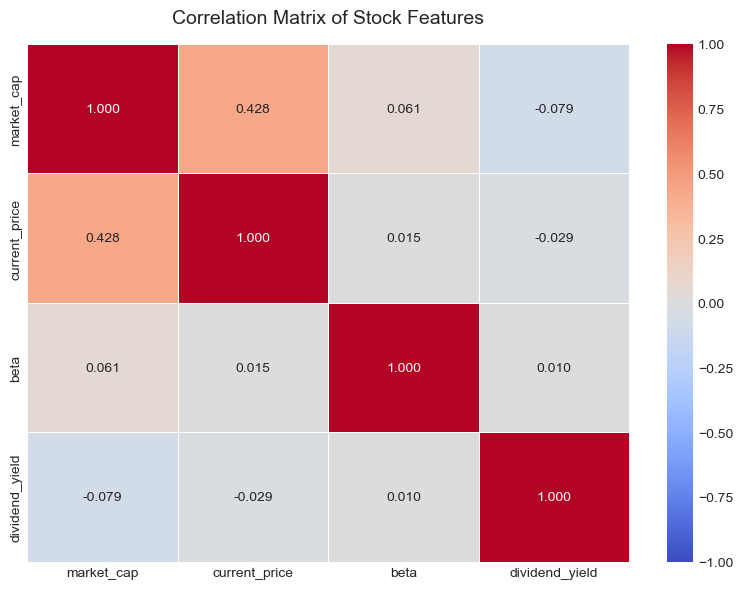

#### 2. Market Cap vs Dividend Yield (%)

*คำถามที่น่าสนใจ: หุ้นขนาดใหญ่ (Large Cap) จ่ายปันผลดีกว่าหุ้นขนาดเล็กจริงหรือไม่?*

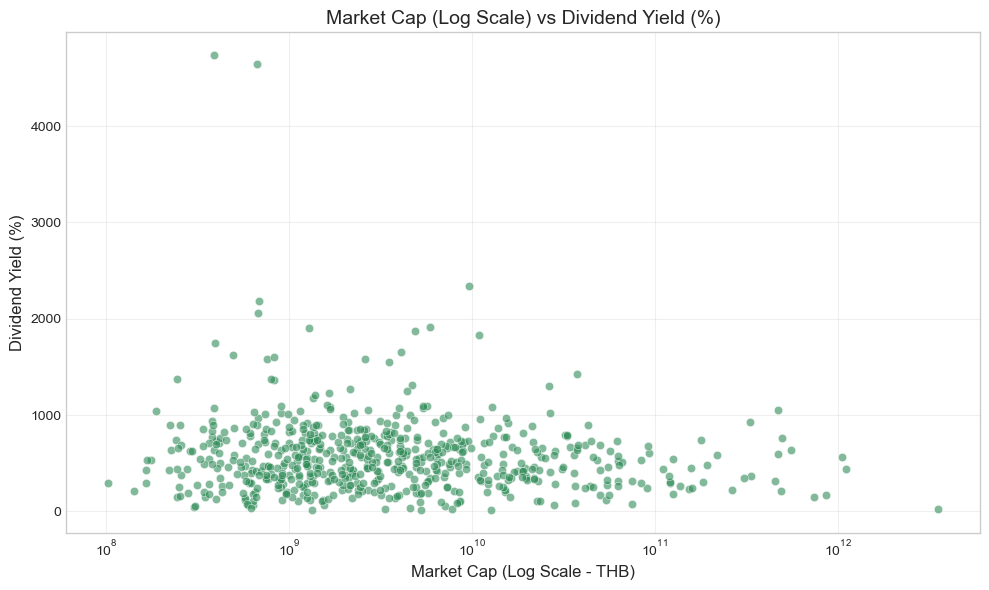

#### 3. Market Cap vs Beta (Volatility against SET Index)

*คำถามที่น่าสนใจ: หุ้นขนาดเล็กมักจะมีความผันผวน (Beta > 1) สูงกว่าหุ้นขนาดใหญ่จริงหรือไม่?*

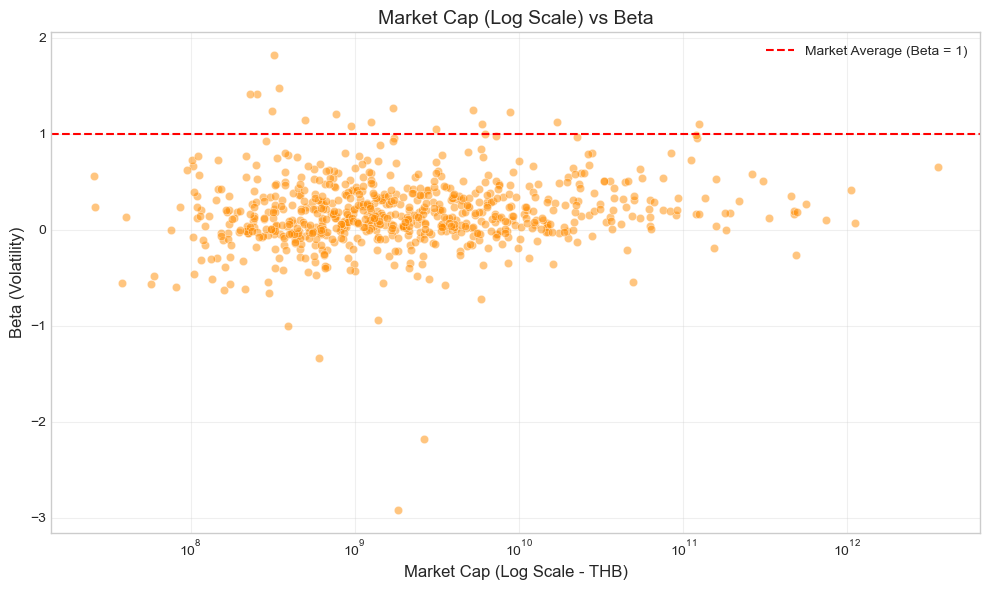

In [17]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# ==========================================
# 0. Connect to Database and Data Preparation
# ==========================================
try:
    conn = psycopg2.connect(
        host="127.0.0.1", database="set_quant", user="postgres", password="Shifa.326459"
    )
    
    query = """
        SELECT 
            s.symbol, 
            s.company_name_th AS company_name, 
            s.industry_group, 
            s.sector_th AS sector,
            y.market_cap, 
            y.current_price, 
            y.beta, 
            y.dividend_yield
        FROM set_companies_list s
        LEFT JOIN yfinance_stock_info y ON s.symbol = y.symbol
    """
    df = pd.read_sql(query, conn)
    conn.close()
    
    # Data Cleaning
    df_clean = df.dropna(subset=['market_cap', 'current_price']).copy()
    df_clean = df_clean[df_clean['market_cap'] > 0]
    
    # จัดการค่าว่าง หรือ '-' ให้เป็น 'N/A' (Not Applicable)
    df_clean['industry_group'] = df_clean['industry_group'].replace('-', 'N/A').fillna('N/A')
    df_clean['sector'] = df_clean['sector'].replace('-', 'N/A').fillna('N/A')

except Exception as e:
    print(f"❌ Connection Error: {e}")

# ==========================================
# 5.1 & 5.2: Overview: Total Stocks and Names
# ==========================================
display(Markdown("### 📌 5.1 & 5.2 Overview: Total Stocks and Names"))

total_stocks = len(df_clean)
stock_list_str = ", ".join(df_clean['symbol'].tolist()[:15]) + " ... (and more)" 

df_overview = pd.DataFrame({
    "Question": ["5.1 How many stocks?", "5.2 List all stock name? (Preview)"],
    "Answer": [total_stocks, stock_list_str]
})
display(df_overview)

# ==========================================
# 5.3 & 5.4: Categories (Industry Group vs Sector)
# ==========================================
display(Markdown("### 📌 5.3 & 5.4 Overview: Stock Categories"))

num_industry = df_clean['industry_group'].nunique()
num_sector = df_clean['sector'].nunique()

df_cat_count = pd.DataFrame({
    "Hierarchy Level": ["Level 1: Industry Group (กลุ่มอุตสาหกรรม)", "Level 2: Sector (หมวดธุรกิจ)"],
    "Total Categories": [num_industry, num_sector],
    "List of Categories (Preview)": [
        ", ".join(df_clean['industry_group'].unique().tolist()[:5]) + " ...",
        ", ".join(df_clean['sector'].unique().tolist()[:5]) + " ..."
    ]
})
display(df_cat_count)

# ==========================================
# 5.5: List stock in each categories
# ==========================================
display(Markdown("### 📌 5.5 List of Stocks in Each Category (Level 1: By Industry Group)"))

df_ind_grouped = df_clean.groupby('industry_group')['symbol'].apply(list).reset_index()
df_ind_grouped['Total Stocks'] = df_ind_grouped['symbol'].apply(len)
df_ind_grouped['Stock List'] = df_ind_grouped['symbol'].apply(lambda x: ", ".join(x[:10]) + ("..." if len(x)>10 else ""))
df_ind_grouped = df_ind_grouped[['industry_group', 'Total Stocks', 'Stock List']].sort_values(by='Total Stocks', ascending=False).reset_index(drop=True)
df_ind_grouped.rename(columns={'industry_group': 'Industry Group'}, inplace=True)
display(df_ind_grouped) 

display(Markdown("### 📌 5.5 List of Stocks in Each Category (Level 2: By Sector)"))

df_sec_grouped = df_clean.groupby('sector')['symbol'].apply(list).reset_index()
df_sec_grouped['Total Stocks'] = df_sec_grouped['symbol'].apply(len)
df_sec_grouped['Stock List'] = df_sec_grouped['symbol'].apply(lambda x: ", ".join(x[:8]) + ("..." if len(x)>8 else ""))
df_sec_grouped = df_sec_grouped[['sector', 'Total Stocks', 'Stock List']].sort_values(by='Total Stocks', ascending=False).reset_index(drop=True)
df_sec_grouped.rename(columns={'sector': 'Sector'}, inplace=True)
display(df_sec_grouped.head(10)) # โชว์ 10 หมวดแรกเพื่อไม่ให้ยาวเกินไป

# ==========================================
# 5.6 & 5.7: Large and Small Market Cap
# ==========================================
display(Markdown("### 📌 5.6 & 5.7 Largest and Smallest Market Cap"))

large_stock = df_clean.loc[df_clean['market_cap'].idxmax()]
small_stock = df_clean.loc[df_clean['market_cap'].idxmin()]

df_minmax_cap = pd.DataFrame({
    "Question": ["5.6 Largest Market Cap", "5.7 Smallest Market Cap"],
    "Symbol": [large_stock['symbol'], small_stock['symbol']],
    "Company Name": [large_stock['company_name'], small_stock['company_name']],
    "Market Cap (THB)": [f"{large_stock['market_cap']:,.2f}", f"{small_stock['market_cap']:,.2f}"]
})
display(df_minmax_cap)

# ==========================================
# 5.8 & 5.9: Sort Ascending and Descending
# ==========================================
display(Markdown("### 📌 5.8 Sort Ascending based on Market Cap (Top 5 Smallest)"))
df_asc = df_clean.sort_values(by='market_cap', ascending=True)[['symbol', 'company_name', 'industry_group', 'market_cap']].head()
df_asc['market_cap'] = df_asc['market_cap'].apply(lambda x: f"{x:,.2f}")
display(df_asc.reset_index(drop=True))

display(Markdown("### 📌 5.9 Sort Descending based on Market Cap (Top 5 Largest)"))
df_desc = df_clean.sort_values(by='market_cap', ascending=False)[['symbol', 'company_name', 'industry_group', 'market_cap']].head()
df_desc['market_cap'] = df_desc['market_cap'].apply(lambda x: f"{x:,.2f}")
display(df_desc.reset_index(drop=True))

# ==========================================
# 5.11 & 5.12: Min and Max Price
# ==========================================
display(Markdown("### 📌 5.11 & 5.12 Minimum and Maximum Price"))

min_price = df_clean.loc[df_clean['current_price'].idxmin()]
max_price = df_clean.loc[df_clean['current_price'].idxmax()]

df_minmax_price = pd.DataFrame({
    "Question": ["5.11 Minimum Price Stock", "5.12 Maximum Price Stock"],
    "Symbol": [min_price['symbol'], max_price['symbol']],
    "Price (THB)": [f"{min_price['current_price']:,.2f}", f"{max_price['current_price']:,.2f}"]
})
display(df_minmax_price)

# ==========================================
# 5.10: Plot Correlation & Interesting Relationships
# ==========================================
display(Markdown("### 📌 5.10 Plot Correlation and Interesting Relationships Based on Market Cap"))

# ตั้งค่าฟอนต์สากลให้กราฟ
plt.rcParams['font.sans-serif'] = ['Arial', 'Tahoma', 'DejaVu Sans']

# ----------------------------------------
# Plot 1: Correlation Matrix Heatmap
# ----------------------------------------
display(Markdown("#### 1. Correlation Matrix Heatmap"))
display(Markdown("*ภาพรวมความสัมพันธ์ระหว่าง Market Cap, ราคา, ความผันผวน (Beta) และ เงินปันผล (Dividend Yield)*"))

plt.figure(figsize=(8, 6))
numeric_cols = ['market_cap', 'current_price', 'beta', 'dividend_yield']
corr_matrix = df_clean[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Stock Features', pad=15, fontsize=14)
plt.tight_layout()
plt.show()

# ----------------------------------------
# Plot 2: Market Cap vs Dividend Yield
# ----------------------------------------
display(Markdown("#### 2. Market Cap vs Dividend Yield (%)"))
display(Markdown("*คำถามที่น่าสนใจ: หุ้นขนาดใหญ่ (Large Cap) จ่ายปันผลดีกว่าหุ้นขนาดเล็กจริงหรือไม่?*"))

plt.figure(figsize=(10, 6))
# กรองข้อมูลเอาเฉพาะตัวที่มีปันผล (ป้องกัน Outlier ที่ทำให้กราฟเบี้ยว)
df_div = df_clean[df_clean['dividend_yield'] > 0].copy()
# แปลง Dividend Yield ให้เป็น %
df_div['dividend_percent'] = df_div['dividend_yield'] * 100 

sns.scatterplot(data=df_div, x='market_cap', y='dividend_percent', alpha=0.6, color='seagreen')
plt.xscale('log') # ใช้ Log scale เพราะขนาด Market Cap ต่างกันมาก
plt.title('Market Cap (Log Scale) vs Dividend Yield (%)', fontsize=14)
plt.xlabel('Market Cap (Log Scale - THB)', fontsize=12)
plt.ylabel('Dividend Yield (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------------------
# Plot 3: Market Cap vs Beta (Volatility)
# ----------------------------------------
display(Markdown("#### 3. Market Cap vs Beta (Volatility against SET Index)"))
display(Markdown("*คำถามที่น่าสนใจ: หุ้นขนาดเล็กมักจะมีความผันผวน (Beta > 1) สูงกว่าหุ้นขนาดใหญ่จริงหรือไม่?*"))

plt.figure(figsize=(10, 6))
df_beta = df_clean.dropna(subset=['beta'])

sns.scatterplot(data=df_beta, x='market_cap', y='beta', alpha=0.5, color='darkorange')
plt.axhline(1.0, color='red', linestyle='--', label='Market Average (Beta = 1)') # ขีดเส้นค่าเฉลี่ยตลาด
plt.xscale('log')
plt.title('Market Cap (Log Scale) vs Beta', fontsize=14)
plt.xlabel('Market Cap (Log Scale - THB)', fontsize=12)
plt.ylabel('Beta (Volatility)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()